<a href="https://colab.research.google.com/github/mdkamrulhasan/data_mining_kdd/blob/main/notebooks/Comparing_distances_in_HD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import statistics
import pandas as pd
import plotly.express as px
import itertools
import scipy.stats as stats

# Problem 1

Helper function definitions

In [ ]:
NB_STEPS = 1000
W_STD = 4
NB_DATA_POINTS = 100

np.random.seed(42)

def plot_graph(_mean, _std, distance_type):
  x_axis = np.arange(_mean - 4*_std, _mean + W_STD*_std, W_STD*_std/NB_STEPS)
  plt.plot(x_axis, norm.pdf(x_axis, _mean, _std))
  plt.title(distance_type)
  plt.show()

def find_distances_distribution(pairs, distance_type, remove_mean):
  if distance_type == 'l1':
    pair_distances = [np.sum(np.abs(px[0] - px[1])) for px in pairs]
  elif distance_type == 'l2':
    pair_distances = [np.linalg.norm(px[0] - px[1]) for px in pairs]
  elif distance_type == 'cosine':
    pair_distances = [1 - np.dot(px[0], px[1]) / (np.linalg.norm(px[0]) * np.linalg.norm(px[1])) for px in pairs]
  else:
    raise ValueError('Invalid distance type')


  if remove_mean:
    pair_distances = (pair_distances - np.mean(pair_distances)) # / np.std(pair_distances)

  _mean, _std = np.round(np.mean(pair_distances),2), np.round(np.std(pair_distances), 2)

  return _mean, _std, pair_distances


def generate_and_analyze_data(distance_type, remove_mean=False):

  # Plot the distributions
  plt.figure(figsize=(12, 8))

  for i in np.arange(2, 12, 2):
    d = 2**i
    data = np.random.randn(NB_DATA_POINTS, d)
    pairs = list(itertools.combinations(data, 2))

    _mean, _std, _ = find_distances_distribution(pairs, distance_type, remove_mean)

    x = np.linspace(_mean - 3*_std, _mean + 3*_std, 100)
    plt.plot(x, stats.norm.pdf(x, _mean, _std),
             label=f'd={d}, mu={_mean}, std={_std}')


    # KDE test
    # _, _, pair_distances = find_distances_distribution(pairs, distance_type, remove_mean)

    # kde = stats.gaussian_kde(pair_distances)
    # plt.plot(pair_distances, kde(pair_distances), label=f'd={d}')



  plt.title(f'Gaussian Fit for {distance_type} Distance')
  plt.xlabel('Distance')
  plt.ylabel('Density')
  plt.legend()


#generate_and_analyze_data('l1')

NameError: name 'np' is not defined

# l1 space data analysis

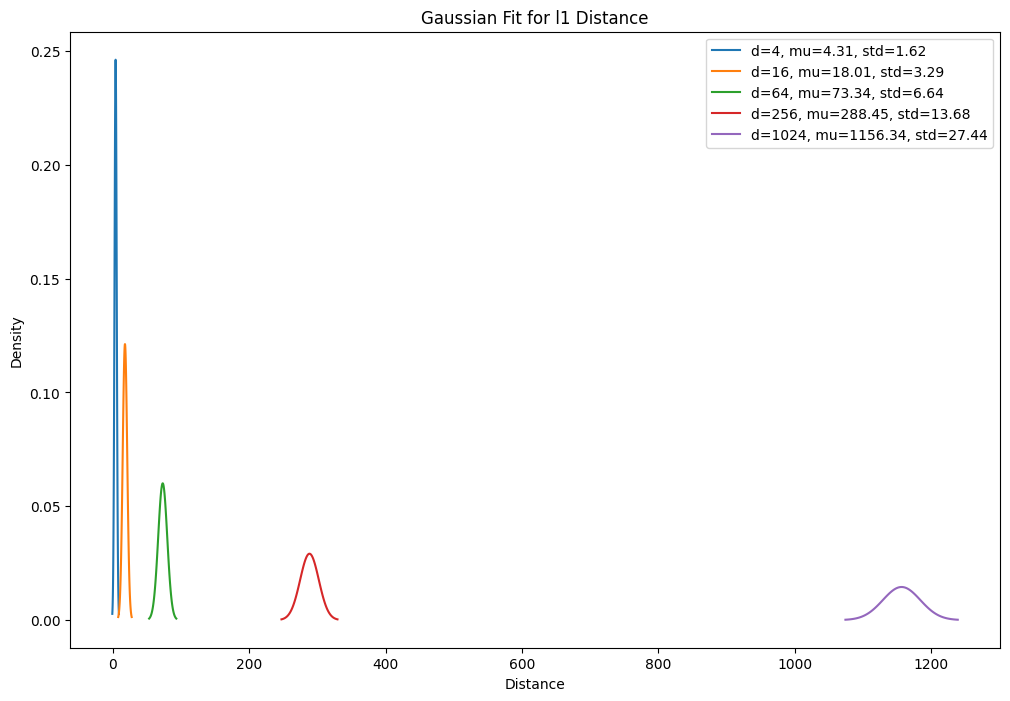

In [ ]:
generate_and_analyze_data('l1')

# Distance analysis in the l2 space

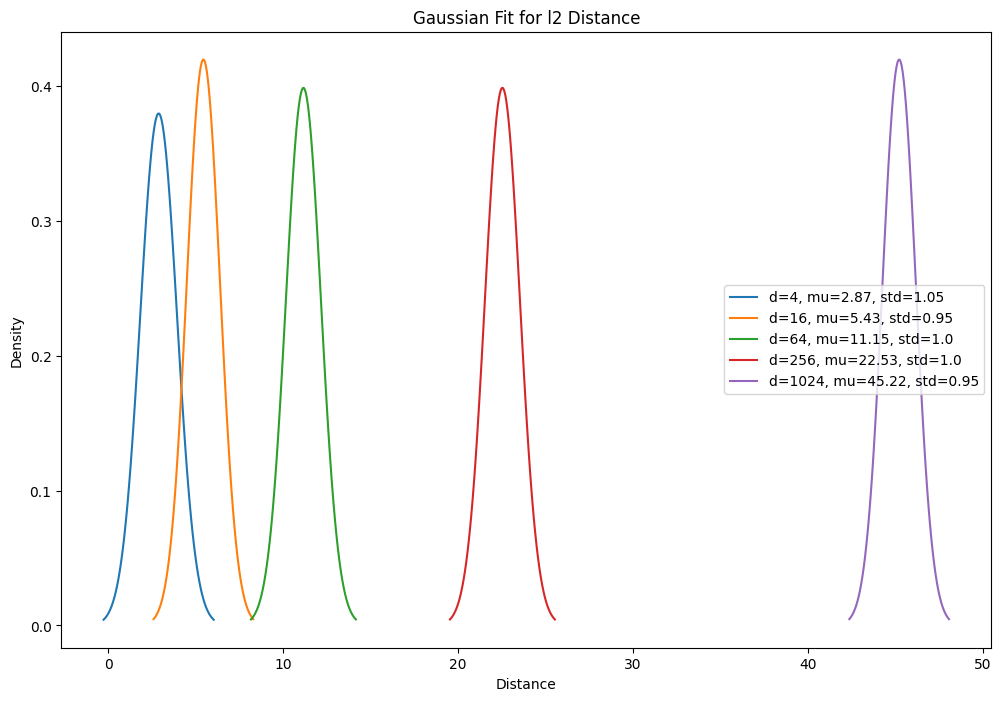

In [ ]:
generate_and_analyze_data('l2')

# Distance analysis in the 'cosine' space

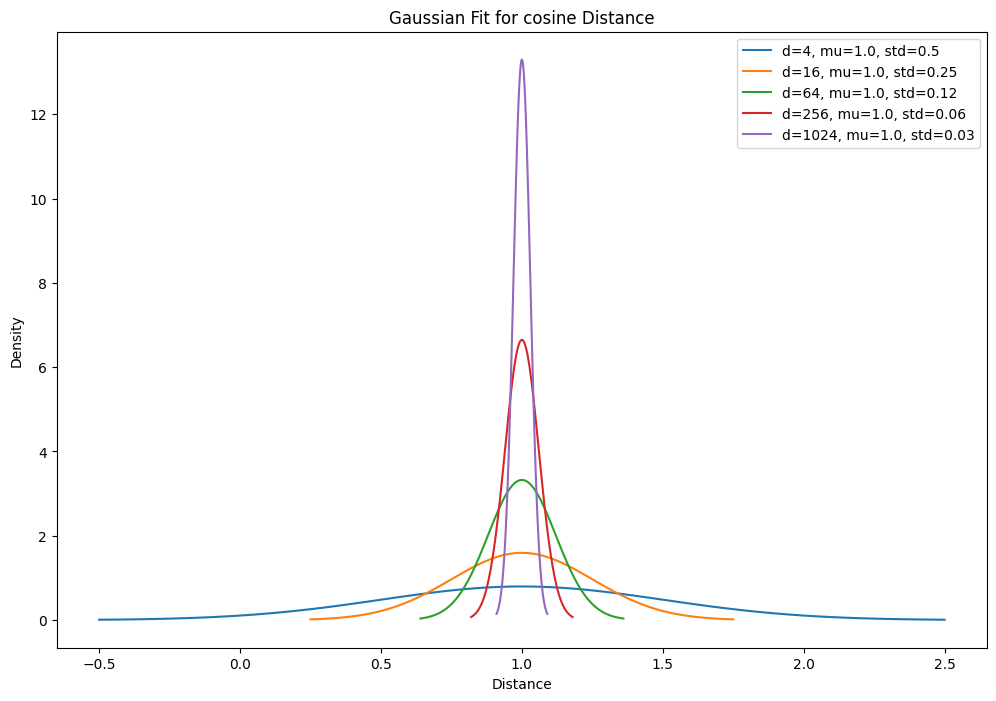

In [ ]:
generate_and_analyze_data('cosine')